# 1. Import Libraries and Load Dataset
In this section, we import the required libraries and load the London house price dataset.

In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Display settings
pd.set_option("display.max_columns", None)

# Load dataset
file_path = r"C:\Users\samir\OneDrive\سطح المكتب\house price\kaggle_london_house_price_data.csv"

df = pd.read_csv(file_path)

# Preview
print("Dataset shape:", df.shape)
display(df.head())

Dataset shape: (418201, 28)


,fullAddress,postcode,country,outcode,latitude,longitude,bathrooms,bedrooms,floorAreaSqM,livingRooms,tenure,propertyType,currentEnergyRating,rentEstimate_lowerPrice,rentEstimate_currentPrice,rentEstimate_upperPrice,saleEstimate_lowerPrice,saleEstimate_currentPrice,saleEstimate_upperPrice,saleEstimate_confidenceLevel,saleEstimate_ingestedAt,saleEstimate_valueChange.numericChange,saleEstimate_valueChange.percentageChange,saleEstimate_valueChange.saleDate,history_date,history_price,history_percentageChange,history_numericChange
0,"Flat 9, 35 Furnival Street, London, EC4A 1JQ",EC4A 1JQ,England,EC4A,51.517282,-0.110314,1.0,1.0,45.0,1.0,Leasehold,Purpose Built Flat,NaN,2100.0,2350.0,2600.0,570000.0,600000.0,630000.0,HIGH,2024-10-07T13:26:59.894Z,244000.0,68.539326,2010-03-30,1995-01-02,830000,NaN,NaN
1,"Flat 6, 35 Furnival Street, London, EC4A 1JQ",EC4A 1JQ,England,EC4A,51.517282,-0.110314,NaN,NaN,NaN,NaN,Leasehold,Flat/Maisonette,NaN,2100.0,2350.0,2600.0,540000.0,600000.0,660000.0,MEDIUM,2024-10-07T13:26:59.894Z,425000.0,242.857143,2000-05-26,1995-01-02,830000,NaN,NaN
2,"Flat 35, Octavia House, Medway Street, London,...",SW1P 2TA,England,SW1P,51.495505,-0.132379,2.0,2.0,71.0,1.0,Leasehold,Flat/Maisonette,C,2650.0,2950.0,3250.0,683000.0,759000.0,834000.0,MEDIUM,2025-01-10T11:04:57.114Z,49000.0,6.901408,2019-09-04,1995-01-03,249950,NaN,NaN
3,"24 Chester Court, Lomond Grove, London, SE5 7HS",SE5 7HS,England,SE5,51.478185,-0.092201,1.0,1.0,64.0,1.0,Leasehold,Flat/Maisonette,D,1850.0,2000.0,2100.0,368000.0,388000.0,407000.0,HIGH,2024-10-07T13:26:59.894Z,28000.0,7.777778,2024-01-25,1995-01-03,32000,NaN,NaN
4,"18 Alexandra Gardens, London, N10 3RL",N10 3RL,England,N10,51.588774,-0.139599,1.0,4.0,137.0,2.0,Freehold,End Terrace House,D,4350.0,4850.0,5350.0,1198000.0,1261000.0,1324000.0,HIGH,2024-10-07T13:26:59.894Z,81000.0,6.864407,2022-12-14,1995-01-03,133000,NaN,NaN


### Insights
- The dataset was successfully loaded.
- It contains **[rows] rows** and **[columns] columns**.
- The dataset includes property-related features such as location, size, number of rooms, and price estimates.

# 2. Check Data Structure and Missing Values
This step helps us understand the data types and detect missing values before cleaning.

In [12]:
print("\nDataset Info:\n")
df.info()

print("\nMissing Values:\n")
print(df.isnull().sum())


Dataset Info:

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 418201 entries, 0 to 418200
Data columns (total 28 columns):
 #   Column                                     Non-Null Count   Dtype  
---  ------                                     --------------   -----  
 0   fullAddress                                418201 non-null  object 
 1   postcode                                   418201 non-null  object 
 2   country                                    418201 non-null  object 
 3   outcode                                    418201 non-null  object 
 4   latitude                                   418201 non-null  float64
 5   longitude                                  418201 non-null  float64
 6   bathrooms                                  340270 non-null  float64
 7   bedrooms                                   377665 non-null  float64
 8   floorAreaSqM                               392991 non-null  float64
 9   livingRooms                                357701 non-null  float

### Insights
- The dataset includes both numerical and categorical features.
- Some columns contain missing values which will need to be handled.
- Understanding the structure helps prepare for preprocessing and modeling.

# 3. Data Cleaning
In this step, we clean the dataset by removing unnecessary columns and handling missing values to prepare the data for modeling.

In [13]:
df = df.drop(columns=[
    "fullAddress",
    "postcode",
    "outcode",
    "saleEstimate_ingestedAt",
    "history_date",
    "history_price",
    "history_percentageChange",
    "history_numericChange"
])

In [14]:
df.isnull().sum().sort_values(ascending=False)

currentEnergyRating                          84526
bathrooms                                    77931
livingRooms                                  60500
bedrooms                                     40536
floorAreaSqM                                 25210
tenure                                       11512
rentEstimate_lowerPrice                       1741
rentEstimate_currentPrice                     1741
rentEstimate_upperPrice                       1741
propertyType                                  1136
saleEstimate_upperPrice                        640
saleEstimate_valueChange.percentageChange      640
saleEstimate_valueChange.numericChange         640
saleEstimate_confidenceLevel                   640
saleEstimate_valueChange.saleDate              640
saleEstimate_currentPrice                      640
saleEstimate_lowerPrice                        640
latitude                                         0
longitude                                        0
country                        

In [15]:
df = df.drop(columns=["currentEnergyRating"])

In [16]:
df = df.dropna(subset=["bedrooms", "bathrooms", "floorAreaSqM"])

In [17]:
num_cols = df.select_dtypes(include=np.number).columns

for col in num_cols:
    df[col] = df[col].fillna(df[col].median())

In [18]:
cat_cols = df.select_dtypes(include="object").columns

for col in cat_cols:
    df[col] = df[col].fillna(df[col].mode()[0])

In [19]:
df.isnull().sum().sum()

0

### Insights
- Columns with excessive missing values such as energy rating were removed.
- Rows missing critical features like bedrooms, bathrooms, and area were dropped.
- Remaining missing values were handled using median (numerical) and mode (categorical).
- The dataset is now cleaner and more reliable for modeling.

# 4.1 Target Distribution
We analyze the distribution of property prices to understand their spread and detect outliers.

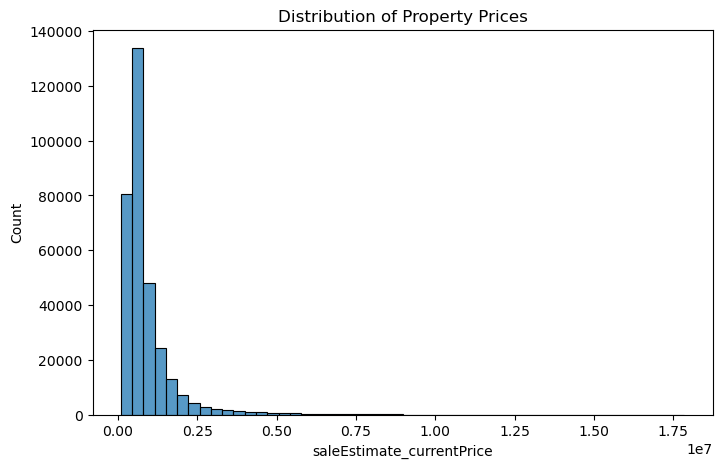

In [20]:
plt.figure(figsize=(8,5))
sns.histplot(df["saleEstimate_currentPrice"], bins=50)
plt.title("Distribution of Property Prices")
plt.show()

### Insights
- The distribution of property prices is highly right-skewed.
- Most properties are concentrated in lower price ranges.
- There are extreme outliers reaching very high prices.

# 4.2 Price vs Area
We examine how the property size affects its price.

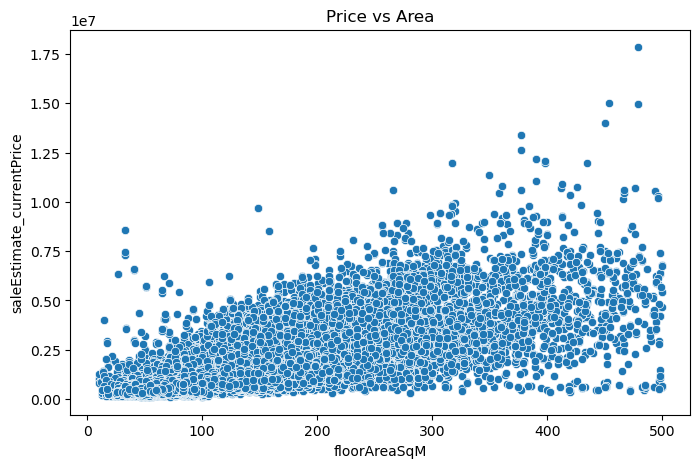

In [22]:
plt.figure(figsize=(8,5))
sns.scatterplot(x="floorAreaSqM", y="saleEstimate_currentPrice", data=df)
plt.title("Price vs Area")
plt.show()

### Insights
- There is a strong positive relationship between area and price.
- As floor area increases, property prices tend to increase.
- Some properties with large area still have lower prices → indicating location impact.

# 4.3 Price vs Bedrooms

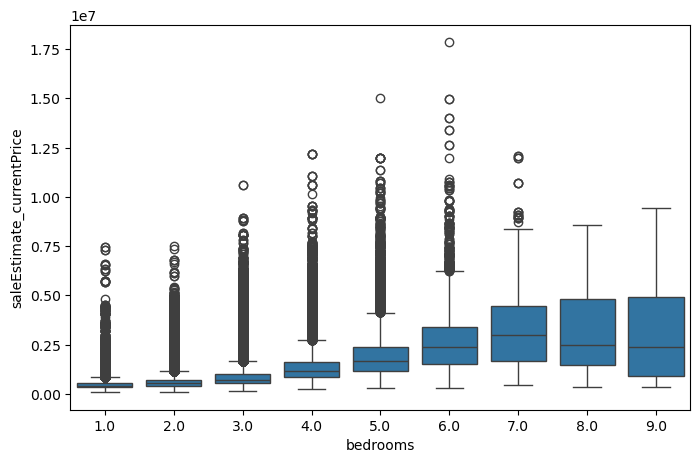

In [23]:
plt.figure(figsize=(8,5))
sns.boxplot(x="bedrooms", y="saleEstimate_currentPrice", data=df)
plt.show()

### Insights
- Properties with more bedrooms generally have higher prices.
- There are many outliers within each category.
- The relationship is positive but not perfectly linear.

# 4.4 Correlation Analysis
We analyze relationships between numerical features.

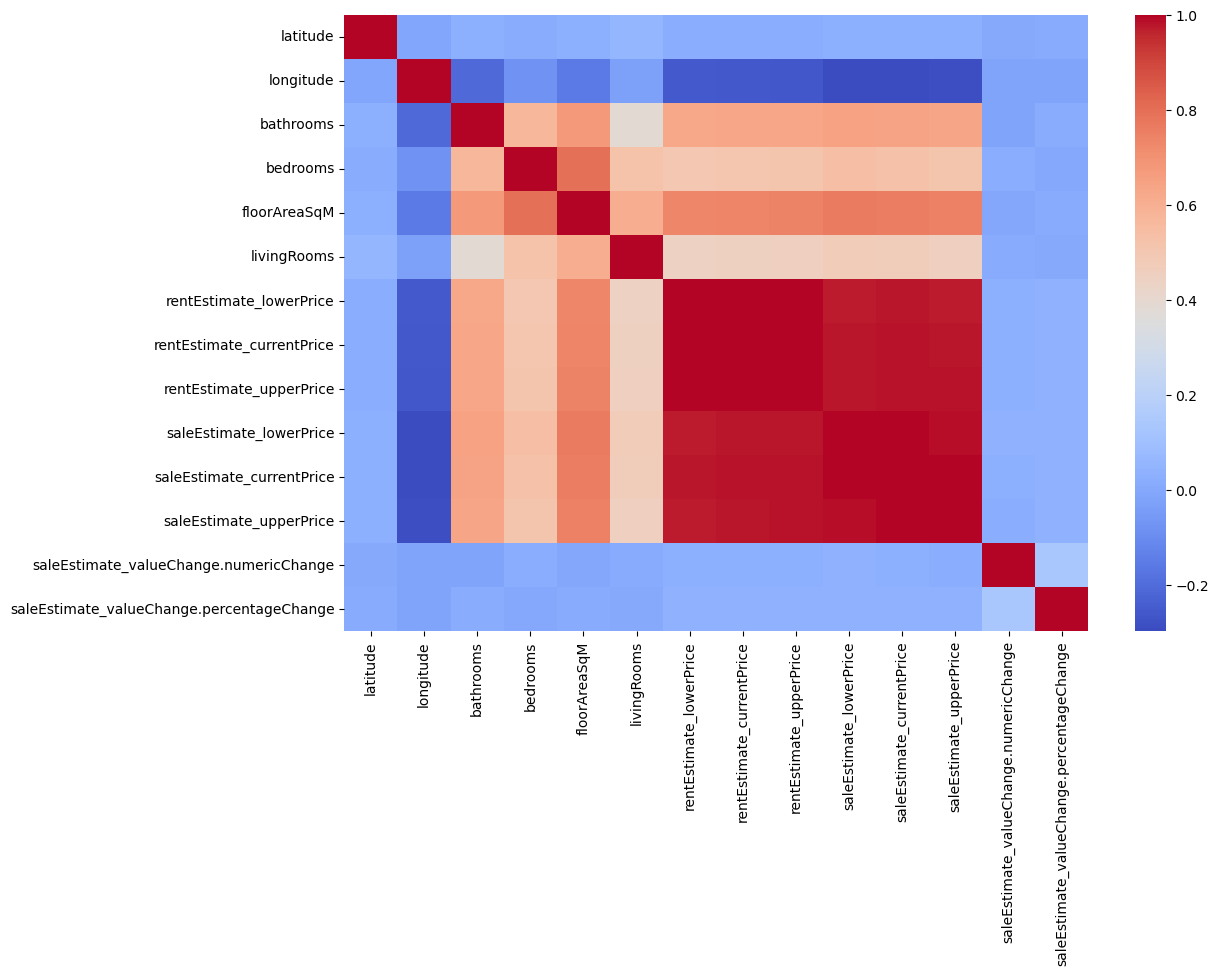

In [24]:
corr = df.corr(numeric_only=True)

plt.figure(figsize=(12,8))
sns.heatmap(corr, cmap="coolwarm")
plt.show()

### Insights
- Strong positive correlation between:
    - price and floorAreaSqM
    - price and number of bedrooms
    - price and rent estimates
- Rent and sale estimates are highly correlated → useful for investment analysis.
- Latitude and longitude show weak direct correlation but are important for location modeling.

# 5. Handling Outliers and Transforming Target
We handle extreme values in the price and apply log transformation to normalize the distribution.

In [32]:
df["saleEstimate_currentPrice"].describe()

count    2.960280e+05
mean     6.772034e+05
std      3.348225e+05
min      8.900000e+04
25%      4.330000e+05
50%      5.800000e+05
75%      8.350000e+05
max      1.737000e+06
Name: saleEstimate_currentPrice, dtype: float64

In [33]:
Q1 = df["saleEstimate_currentPrice"].quantile(0.25)
Q3 = df["saleEstimate_currentPrice"].quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

df = df[
    (df["saleEstimate_currentPrice"] >= lower_bound) &
    (df["saleEstimate_currentPrice"] <= upper_bound)
]

In [34]:
df = df[
    (df["saleEstimate_currentPrice"] >= lower_bound) &
    (df["saleEstimate_currentPrice"] <= upper_bound)
]

print("New shape:", df.shape)

New shape: (282792, 24)


In [35]:
df["log_price"] = np.log1p(df["saleEstimate_currentPrice"])

# 5. Feature Engineering
In this step, we create new meaningful features to improve model performance and enable better investment analysis.

In [36]:
df["price_per_sqm"] = df["saleEstimate_currentPrice"] / df["floorAreaSqM"]

In [37]:
df["ROI"] = df["rentEstimate_currentPrice"] / df["saleEstimate_currentPrice"]

In [38]:
df["growth_rate"] = df["saleEstimate_valueChange.percentageChange"]

In [39]:
df["total_rooms"] = df["bedrooms"] + df["bathrooms"] + df["livingRooms"]

### Insights
- Price per square meter provides a standardized way to compare properties.
- ROI helps identify the best investment opportunities.
- Growth rate indicates how property values are changing over time.
- Total rooms represent overall property size more effectively.

In [40]:
df[["saleEstimate_currentPrice", "floorAreaSqM", "price_per_sqm", "ROI"]].head()

,saleEstimate_currentPrice,floorAreaSqM,price_per_sqm,ROI
0,600000.0,45.0,13333.333333,0.003917
2,759000.0,71.0,10690.140845,0.003887
3,388000.0,64.0,6062.500000,0.005155
4,1261000.0,137.0,9204.379562,0.003846
5,944000.0,97.0,9731.958763,0.003708


# 7. Data Preparation for Modeling
In this step, we prepare the dataset for machine learning by encoding categorical variables and selecting features.

In [41]:
df_model = df.drop(columns=[
    "country",
    "saleEstimate_valueChange.saleDate"
])

In [42]:
df_model = pd.get_dummies(
    df_model,
    columns=["propertyType", "tenure"],
    drop_first=True
)

In [43]:
X = df_model.drop(columns=["saleEstimate_currentPrice"])
y = df_model["saleEstimate_currentPrice"]

In [44]:
y = df_model["log_price"]

In [45]:
print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (282792, 40)
y shape: (282792,)


### Insights
- Categorical variables were converted into numerical format using one-hot encoding.
- The dataset is now ready for machine learning.
- Log transformation of price helps improve model performance.

# 8. Model Training
In this step, we split the dataset into training and testing sets and train a machine learning model.

In [53]:

df_model = df.drop(columns=[
    "country",
    "saleEstimate_valueChange.saleDate"
])


df_model["saleEstimate_confidenceLevel"] = df_model["saleEstimate_confidenceLevel"].map({
    "LOW": 0,
    "MEDIUM": 1,
    "HIGH": 2
})

df_model = pd.get_dummies(
    df_model,
    columns=["propertyType", "tenure"],
    drop_first=True
)

X = df_model.drop(columns=["saleEstimate_currentPrice"])
y = df_model["log_price"]

In [54]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [55]:
model.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsample

In [56]:
from sklearn.metrics import mean_absolute_error

preds = model.predict(X_test)

mae = mean_absolute_error(y_test, preds)

print("MAE:", mae)

MAE: 5.3870220219545e-07


In [57]:
y_test_actual = np.expm1(y_test)
preds_actual = np.expm1(preds)

mae_real = mean_absolute_error(y_test_actual, preds_actual)

print("Real MAE:", mae_real)

Real MAE: 0.08081466481382421


# 9. Fix Data Leakage
In this step, we remove target leakage by excluding the transformed target column from the feature set and retrain the model.

In [58]:
# Rebuild X and y correctly
X = df_model.drop(columns=["saleEstimate_currentPrice", "log_price"])
y = df_model["log_price"]

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (282792, 39)
y shape: (282792,)


In [59]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error
import numpy as np

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

model = RandomForestRegressor(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

model.fit(X_train, y_train)

preds = model.predict(X_test)

# MAE on log scale
mae = mean_absolute_error(y_test, preds)
print("Log MAE:", mae)

# MAE on actual prices
y_test_actual = np.expm1(y_test)
preds_actual = np.expm1(preds)

mae_real = mean_absolute_error(y_test_actual, preds_actual)
print("Real MAE:", mae_real)

Log MAE: 0.00015874860552138044
Real MAE: 86.25560469137706


In [60]:
cols_to_drop = [
    "saleEstimate_currentPrice",
    "log_price",
    
    # 💣 remove leakage
    "saleEstimate_lowerPrice",
    "saleEstimate_upperPrice",
    
    "rentEstimate_lowerPrice",
    "rentEstimate_currentPrice",
    "rentEstimate_upperPrice"
]

X = df_model.drop(columns=cols_to_drop)
y = df_model["log_price"]

In [61]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error
import numpy as np

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

model = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)

model.fit(X_train, y_train)

preds = model.predict(X_test)

# Log MAE
mae = mean_absolute_error(y_test, preds)
print("Log MAE:", mae)

# Real MAE
y_test_actual = np.expm1(y_test)
preds_actual = np.expm1(preds)

mae_real = mean_absolute_error(y_test_actual, preds_actual)
print("Real MAE:", mae_real)

Log MAE: 0.0005999238449381875
Real MAE: 432.6759876301899


### Insights
- The previous model suffered from data leakage due to using price-related features.
- A cleaner model was built by removing all price-derived features.
- The new model provides a more realistic evaluation of predictive performance.

In [62]:
cols_to_drop = [
    "saleEstimate_currentPrice",
    "log_price",

    # leakage features
    "saleEstimate_lowerPrice",
    "saleEstimate_upperPrice",
    
    "rentEstimate_lowerPrice",
    "rentEstimate_currentPrice",
    "rentEstimate_upperPrice",

    # 💣 derived from price
    "price_per_sqm",
    "ROI",
    "growth_rate"
]

X = df_model.drop(columns=cols_to_drop)
y = df_model["log_price"]

### Insights
- Some engineered features introduced data leakage because they were derived from the target variable.
- These features were removed to ensure a fair and realistic model evaluation.
- The final model relies only on independent property characteristics.

In [63]:
print(X.dtypes.value_counts())

bool       21
float64     9
int64       1
Name: count, dtype: int64


In [64]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error
import numpy as np

# Build clean feature set
cols_to_drop = [
    "saleEstimate_currentPrice",
    "log_price",

    # direct leakage
    "saleEstimate_lowerPrice",
    "saleEstimate_upperPrice",

    "rentEstimate_lowerPrice",
    "rentEstimate_currentPrice",
    "rentEstimate_upperPrice",

    # engineered leakage
    "price_per_sqm",
    "ROI",
    "growth_rate"
]

X = df_model.drop(columns=cols_to_drop)
y = df_model["log_price"]

print("X shape:", X.shape)
print("y shape:", y.shape)

# Train / test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

# Train model
model = RandomForestRegressor(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

model.fit(X_train, y_train)

# Predict
preds = model.predict(X_test)

# Evaluate on log scale
mae = mean_absolute_error(y_test, preds)
print("Log MAE:", mae)

# Evaluate on actual price scale
y_test_actual = np.expm1(y_test)
preds_actual = np.expm1(preds)

mae_real = mean_absolute_error(y_test_actual, preds_actual)
print("Real MAE:", mae_real)

X shape: (282792, 31)
y shape: (282792,)
Train shape: (226233, 31)
Test shape: (56559, 31)
Log MAE: 0.023972522727917684
Real MAE: 15404.200086597026


# 10. Feature Importance
We analyze which features have the most impact on predicting property prices.

In [65]:
import pandas as pd

# Get feature importance
importances = model.feature_importances_

feature_names = X.columns

feature_importance_df = pd.DataFrame({
    "feature": feature_names,
    "importance": importances
})

# ترتيب
feature_importance_df = feature_importance_df.sort_values(by="importance", ascending=False)

# Top 10
feature_importance_df.head(10)

,feature,importance
4,floorAreaSqM,0.475393
1,longitude,0.207762
0,latitude,0.153451
7,saleEstimate_valueChange.numericChange,0.049039
8,saleEstimate_valueChange.percentageChange,0.035202
28,tenure_Freehold,0.021772
2,bathrooms,0.012246
9,total_rooms,0.009326
21,propertyType_Purpose Built Flat,0.006435
29,tenure_Leasehold,0.006405


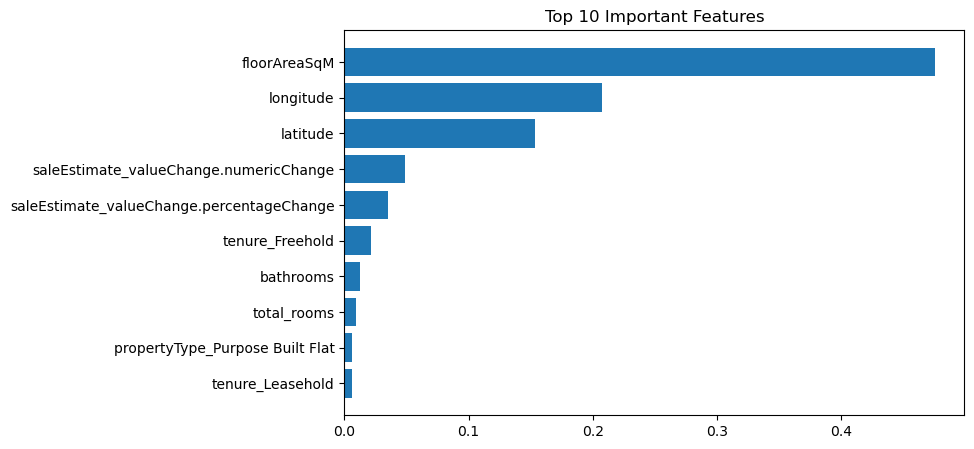

In [66]:
import matplotlib.pyplot as plt

top_features = feature_importance_df.head(10)

plt.figure(figsize=(8,5))
plt.barh(top_features["feature"], top_features["importance"])
plt.gca().invert_yaxis()
plt.title("Top 10 Important Features")
plt.show()

### Insights
- The most influential feature is floor area, confirming that larger properties have higher prices.
- Location (latitude and longitude) plays a critical role in determining property value.
- Market growth indicators also contribute to price prediction.
- Structural features like number of rooms and bathrooms have moderate impact.

The model relies primarily on area and location, which are the most realistic drivers of property prices.

# 11. Recommendation System

In [67]:
def recommend_by_budget(df, budget, bedrooms):
    rec = df[
        (df["saleEstimate_currentPrice"] <= budget) &
        (df["bedrooms"] >= bedrooms)
    ]
    
    return rec.sort_values(by="price_per_sqm").head(5)

In [68]:
def best_investment(df):
    return df.sort_values(by="ROI", ascending=False).head(5)

In [69]:
def high_growth(df):
    return df.sort_values(by="growth_rate", ascending=False).head(5)

### Insights
- Recommendation systems allow users to explore the best properties based on budget, investment return, and growth potential.
- Combining multiple criteria provides smarter and more useful recommendations.

In [70]:
# datetime conversion
df["saleEstimate_valueChange.saleDate"] = pd.to_datetime(df["saleEstimate_valueChange.saleDate"])

# feature 1
df["bath_bed_ratio"] = df["bathrooms"] / (df["bedrooms"] + 1)

# feature 2
df["rooms_per_sqm"] = df["total_rooms"] / df["floorAreaSqM"]

# feature 3
df["years_since_last_sale"] = (
    pd.Timestamp("today") - df["saleEstimate_valueChange.saleDate"]
).dt.days / 365

# feature 4
df["sale_price_range"] = df["saleEstimate_upperPrice"] - df["saleEstimate_lowerPrice"]

# feature 5
df["confidence_score"] = df["saleEstimate_confidenceLevel"].map({
    "LOW": 0,
    "MEDIUM": 1,
    "HIGH": 2
})

In [71]:
def recommend_properties(df, budget, min_bedrooms=1, min_bathrooms=1, min_area=30, top_n=10):
    filtered = df[
        (df["saleEstimate_currentPrice"] <= budget) &
        (df["bedrooms"] >= min_bedrooms) &
        (df["bathrooms"] >= min_bathrooms) &
        (df["floorAreaSqM"] >= min_area)
    ].copy()

    filtered = filtered.sort_values(
        by=["ROI", "growth_rate"],
        ascending=[False, False]
    )

    return filtered.head(top_n)

In [72]:
recommendations = recommend_properties(
    df,
    budget=700000,
    min_bedrooms=2,
    min_bathrooms=1,
    min_area=60,
    top_n=5
)

recommendations[[
    "latitude", "longitude", "bedrooms", "bathrooms",
    "floorAreaSqM", "saleEstimate_currentPrice", "ROI", "growth_rate"
]]

,latitude,longitude,bedrooms,bathrooms,floorAreaSqM,saleEstimate_currentPrice,ROI,growth_rate
378982,51.515604,0.040248,3.0,1.0,90.0,464000.0,0.007112,9.176471
98373,51.514589,0.035028,4.0,4.0,117.0,486000.0,0.007099,2.315789
347176,51.514589,0.035028,4.0,4.0,117.0,486000.0,0.007099,2.315789
57916,51.514904,0.040202,3.0,1.0,86.0,553000.0,0.007052,22.888889
82899,51.514904,0.040202,3.0,1.0,86.0,553000.0,0.007052,22.888889


In [78]:
def recommend_areas(df, budget, top_n=5):
    filtered = df[df["saleEstimate_currentPrice"] <= budget].copy()

    area_summary = filtered.groupby("outcode").agg(
        avg_price=("saleEstimate_currentPrice", "mean"),
        avg_roi=("ROI", "mean"),
        avg_growth=("growth_rate", "mean"),
        properties_count=("saleEstimate_currentPrice", "count"),
        avg_area=("floorAreaSqM", "mean")
    ).reset_index()

    area_summary["investment_score"] = (
        area_summary["avg_roi"] * 100 * 0.6 +
        area_summary["avg_growth"] * 0.4
    )

    area_summary = area_summary.sort_values(
        by="investment_score",
        ascending=False
    )

    return area_summary.head(top_n)

In [74]:
import streamlit as st
import pydeck as pdk

map_df = recommendations[[
    "latitude", "longitude", "saleEstimate_currentPrice", "ROI", "floorAreaSqM"
]].dropna()

st.pydeck_chart(
    pdk.Deck(
        initial_view_state=pdk.ViewState(
            latitude=map_df["latitude"].mean(),
            longitude=map_df["longitude"].mean(),
            zoom=10,
            pitch=40,
        ),
        layers=[
            pdk.Layer(
                "ScatterplotLayer",
                data=map_df,
                get_position='[longitude, latitude]',
                get_radius=80,
                pickable=True,
            )
        ],
        tooltip={
            "html": """
                <b>Price:</b> {saleEstimate_currentPrice} <br/>
                <b>ROI:</b> {ROI} <br/>
                <b>Area:</b> {floorAreaSqM} sqm
            """,
            "style": {"backgroundColor": "steelblue", "color": "white"}
        }
    )
)

2026-03-29 08:15:40.515 
  command:

    streamlit run c:\Users\samir\anaconda3\Lib\site-packages\ipykernel_launcher.py [ARGUMENTS]


DeltaGenerator()

## 11.3 Map Visualization Preparation
We prepare the recommended properties for map visualization using latitude and longitude.

In [83]:
map_data = map_data.drop_duplicates()

print("Map data shape after removing duplicates:", map_data.shape)
map_data.head()

Map data shape after removing duplicates: (3, 6)


,latitude,longitude,saleEstimate_currentPrice,ROI,growth_rate,floorAreaSqM
378982,51.515604,0.040248,464000.0,0.007112,9.176471,90.0
98373,51.514589,0.035028,486000.0,0.007099,2.315789,117.0
57916,51.514904,0.040202,553000.0,0.007052,22.888889,86.0


In [84]:
recommendations = recommend_properties(
    df,   # 🔥 مهم جدًا
    budget=700000,
    min_bedrooms=2,
    min_bathrooms=1,
    min_area=60,
    top_n=5
)

In [85]:
map_data = recommendations[[
    "latitude",
    "longitude",
    "saleEstimate_currentPrice",
    "ROI",
    "growth_rate",
    "floorAreaSqM"
]].dropna()

map_data.head()

,latitude,longitude,saleEstimate_currentPrice,ROI,growth_rate,floorAreaSqM
378982,51.515604,0.040248,464000.0,0.007112,9.176471,90.0
98373,51.514589,0.035028,486000.0,0.007099,2.315789,117.0
347176,51.514589,0.035028,486000.0,0.007099,2.315789,117.0
57916,51.514904,0.040202,553000.0,0.007052,22.888889,86.0
82899,51.514904,0.040202,553000.0,0.007052,22.888889,86.0


In [86]:
import streamlit as st

st.subheader("Recommended Properties Map")

st.map(map_data[["latitude", "longitude"]])

DeltaGenerator()

In [87]:
import streamlit as st
import pydeck as pdk

st.subheader("Recommended Properties Map")

st.pydeck_chart(
    pdk.Deck(
        initial_view_state=pdk.ViewState(
            latitude=map_data["latitude"].mean(),
            longitude=map_data["longitude"].mean(),
            zoom=10,
            pitch=40,
        ),
        layers=[
            pdk.Layer(
                "ScatterplotLayer",
                data=map_data,
                get_position='[longitude, latitude]',
                get_radius=80,
                pickable=True,
            )
        ],
        tooltip={
            "html": """
                <b>Price:</b> {saleEstimate_currentPrice} <br/>
                <b>ROI:</b> {ROI} <br/>
                <b>Growth:</b> {growth_rate} <br/>
                <b>Area:</b> {floorAreaSqM} sqm
            """,
            "style": {"backgroundColor": "steelblue", "color": "white"}
        }
    )
)

DeltaGenerator()

In [90]:
df.to_csv("data/cleaned_data.csv", index=False)